# Les bulles diaboliques de Minkowski — géométrie des nombres calculée

**Série Serre 100** (EPIC [#16334](https://github.com/jsboige/CoursIA/issues/16334), grain 3 — exposé van Handel, *mercredi 9h30*). Serre a puisé toute sa vie dans la géométrie des nombres de Minkowski ; ce notebook en calcule les trois gestes fondateurs :

- **empilements de sphères** : la densité d'un réseau se *mesure* — π/4 pour le réseau carré, π/√12 pour l'hexagonal (Thue, optimal en 2D), π/(3√2) ≈ 0,7405 pour le FCC (la constante de Kepler, démontrée par Hales en 1998) ;
- **le théorème de Minkowski** : un convexe symétrique de volume > 2ⁿ·det(Λ) contient un point réseau non nul — vérifié **sur la borne** (le carré ouvert de volume exactement 4 est vide : l'inégalité stricte est nécessaire) ;
- **le clou** : la preuve de **Fermat** — tout premier $p \equiv 1 \pmod 4$ est somme de deux carrés — *par Minkowski*, exécutée de bout en bout sur 29 premiers : réseau $\Lambda_k$ d'indice $p$, disque de rayon $\sqrt{2p}$, énumération, $a^2 + b^2 = p$.

Et en dimension haute, le contre-intuitif devient visible : la borne de Minkowski-Hlawka s'effondre en $2^{1-n}$ pendant que les réseaux exceptionnels E8 et Leech planent 16 000 fois au-dessus.

## Plan

1. Réseaux et densité d'empilement — Thue en 2D, mesuré
2. Le théorème de Minkowski — vérifié sur la borne
3. Fermat par Minkowski — $p = a^2 + b^2$ exécuté
4. Kepler en 3D — la constante 0,7405 et le FCC
5. Dimensions hautes — le trou entre Minkowski-Hlawka et Leech
6. Exercices

In [1]:
# Dependances : stdlib (math, itertools) + matplotlib inline headless.
import matplotlib
matplotlib.use("module://matplotlib_inline.backend_inline")
import matplotlib.pyplot as plt
from math import pi, sqrt, gamma
from itertools import product as iproduct
print("imports OK")

imports OK


## 1. Réseaux et densité d'empilement

Un **réseau** de $\mathbb{R}^n$, c'est $\Lambda = A \cdot \mathbb{Z}^n$ pour une matrice $A$ inversible ; son **déterminant** $\det(\Lambda) = |\det A|$ est le volume de sa maille élémentaire. On y empile des sphères identiques centrées sur les points du réseau, de rayon $r = $ demi de la **distance minimale** entre points (les sphères se touchent sans se chevaucher). La **densité** de l'empilement — la proportion de l'espace couverte — se calcule exactement :

$$\Delta(\Lambda) = \frac{\mathrm{vol}(B_n(r))}{\det(\Lambda)}, \qquad \mathrm{vol}(B_n(r)) = \frac{\pi^{n/2} r^n}{\Gamma(n/2 + 1)}.$$

En 2D, deux réseaux suffisent à voir la structure : le **carré** et l'**hexagonal**.

In [2]:
def vol_boule(n, r):
    return pi ** (n / 2) * r ** n / gamma(n / 2 + 1)

# Reseau carre : maille 1x1, distance minimale 1, r = 1/2
d_carre = vol_boule(2, 0.5) / 1.0
# Reseau hexagonal A2 : colonnes (1, 0) et (1/2, sqrt(3)/2)
A_hex = ((1.0, 0.5), (0.0, sqrt(3) / 2))
det_hex = abs(A_hex[0][0] * A_hex[1][1] - A_hex[0][1] * A_hex[1][0])
d_hex = vol_boule(2, 0.5) / det_hex
print(f"carre     : densite = {d_carre:.6f} = pi/4")
print(f"hexagonal : densite = {d_hex:.6f} = pi/sqrt(12)")
print(f"Thue (1910) : l'hexagonal est optimal parmi TOUS les empilements 2D")

carre     : densite = 0.785398 = pi/4
hexagonal : densite = 0.906900 = pi/sqrt(12)
Thue (1910) : l'hexagonal est optimal parmi TOUS les empilements 2D


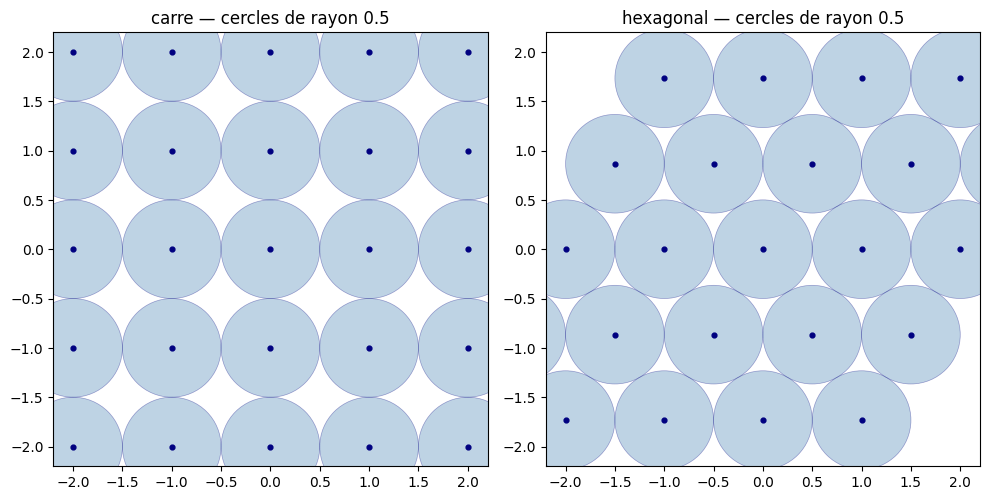

In [3]:
# Les deux empilements, rendus visibles (cercles de rayon r = demi-distance minimale)
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
for ax, (nom, A, r) in zip(axes, [("carre", ((1.0, 0.0), (0.0, 1.0)), 0.5),
                                  ("hexagonal", A_hex, 0.5)]):
    pts = [(A[0][0] * u + A[0][1] * v, A[1][0] * u + A[1][1] * v)
           for u in range(-2, 3) for v in range(-2, 3)]
    ax.set_aspect("equal")
    ax.set_title(f"{nom} — cercles de rayon {r}")
    ax.scatter([p[0] for p in pts], [p[1] for p in pts], s=12, color="navy", zorder=2)
    for x, y in pts:
        ax.add_patch(plt.Circle((x, y), r, color="steelblue", alpha=0.35, ec="navy", lw=0.5))
    ax.set_xlim(-2.2, 2.2)
    ax.set_ylim(-2.2, 2.2)
plt.tight_layout()
plt.show()

**Lecture** : dans le réseau carré, les cercles laissent des creux aux centres des faces ; dans l'hexagonal, chaque cercle s'inscrit dans une alvéole à 6 voisins — les creux disparaissent presque. C'est exactement le gain $\pi/\sqrt{12} - \pi/4 \approx 0{,}1215$ : **12 points de densité gratuits** par un simple cisaillement de la maille.

## 2. Le théorème de Minkowski — et il est sharp

> **Théorème (Minkowski 1896).** Soit $\Lambda$ un réseau de $\mathbb{R}^n$ et $S$ un convexe **symétrique** ($S = -S$). Si $\mathrm{vol}(S) > 2^n \det(\Lambda)$, alors $S$ contient un point de $\Lambda \smallsetminus \{0\}$.

Le résultat est un pont entre le **volume** (continu) et les **points entiers** (discrets) — tout le machinery de la géométrie des nombres. Deux mesures sur $\mathbb{Z}^2$ (où $2^n \det = 4$) : le théorème est **optimal**, car le carré *ouvert* $(-1,1)^2$, de volume exactement $4$, ne contient aucun point non nul.

In [4]:
# La borne est SHARP : carre ouvert de volume exactement 4 = 2^2 . det(Z^2)
pts_bord = [(a, b) for a, b in iproduct(range(-2, 3), repeat=2)
            if (a, b) != (0, 0) and abs(a) < 1 and abs(b) < 1]
print(f"carre ouvert (-1,1)^2 : vol = 4, points Z^2 non nuls dedans = {len(pts_bord)}")
print("-> l'inegalite STRICTE de Minkowski est necessaire : la borne 2^n det est atteinte")

# Et un des le volume depasse 4, un point apparait : disque de rayon 1.2
r_c = 1.2
pts_disque = [(a, b) for a, b in iproduct(range(-2, 3), repeat=2)
              if a * a + b * b < r_c * r_c and (a, b) != (0, 0)]
print(f"disque r={r_c} : vol = {pi * r_c ** 2:.3f} > 4 -> contient {pts_disque}")

carre ouvert (-1,1)^2 : vol = 4, points Z^2 non nuls dedans = 0
-> l'inegalite STRICTE de Minkowski est necessaire : la borne 2^n det est atteinte
disque r=1.2 : vol = 4.524 > 4 -> contient [(-1, 0), (0, -1), (0, 1), (1, 0)]


## 3. Le clou : Fermat par Minkowski, exécuté

> **Théorème (Fermat).** Tout nombre premier $p \equiv 1 \pmod 4$ est somme de deux carrés.

La preuve par Minkowski tient en quatre gestes, chacun calculable :

1. **Racine de $-1$** : comme $p \equiv 1 \pmod 4$, il existe $k$ avec $k^2 \equiv -1 \pmod p$ (trouvé par énumération).
2. **Le réseau** : $\Lambda_k = \{(a,b) \in \mathbb{Z}^2 : a \equiv k\,b \pmod p\}$ est un réseau d'**indice $p$** (noyau de l'application surjective $(a,b) \mapsto a - kb \bmod p$), donc $\det(\Lambda_k) = p$.
3. **Minkowski** : le disque ouvert de rayon $\sqrt{2p}$ a une aire $2\pi p > 4p = 2^2 \det(\Lambda_k)$ : il contient un $(a,b) \neq 0$ du réseau, avec $a^2 + b^2 < 2p$.
4. **Conclusion** : $a^2 + b^2 \equiv (k^2 + 1)b^2 \equiv 0 \pmod p$, et $0 < a^2 + b^2 < 2p$ force $a^2 + b^2 = p$. $\blacksquare$

Une preuve du XVIIᵉ siècle, devenue une équation du XVIIIᵉ, exécutée ligne à ligne :

In [5]:
def racine_de_moins_un(p):
    """k tel que k^2 = -1 (mod p), par enumeration (existe ssi p = 1 mod 4)."""
    for k in range(2, p):
        if k * k % p == p - 1:
            return k
    return None

def deux_carres_minkowski(p):
    """Preuve de Fermat par Minkowski : renvoie (k, (a, b)) avec a^2 + b^2 = p."""
    k = racine_de_moins_un(p)
    R, cands = sqrt(2 * p), []
    for b in range(-int(R) - 1, int(R) + 2):
        for a in range(-int(R) - 1, int(R) + 2):
            if (a, b) != (0, 0) and a * a + b * b < 2 * p and (a - k * b) % p == 0:
                cands.append((a, b))
    a, b = cands[0]
    assert a * a + b * b == p
    return k, (a, b)

premiers = [p for p in range(5, 300, 4)
            if all(p % q for q in range(2, int(p ** 0.5) + 1))]
print(f"Execution sur les {len(premiers)} premiers p = 1 mod 4 inferieurs a 300 :")
for p in premiers[:5] + premiers[-2:]:
    k, (a, b) = deux_carres_minkowski(p)
    print(f"  p = {p:3d} : k = {k:3d}, point du reseau -> {a}^2 + {b}^2 = {p}")
for p in premiers:
    deux_carres_minkowski(p)
print(f"-> {len(premiers)}/{len(premiers)} : la preuve s'execute sans exception")

Execution sur les 29 premiers p = 1 mod 4 inferieurs a 300 :
  p =   5 : k =   2, point du reseau -> 1^2 + -2^2 = 5
  p =  13 : k =   5, point du reseau -> -2^2 + -3^2 = 13
  p =  17 : k =   4, point du reseau -> 1^2 + -4^2 = 17
  p =  29 : k =  12, point du reseau -> -2^2 + -5^2 = 29
  p =  37 : k =   6, point du reseau -> 1^2 + -6^2 = 37
  p = 281 : k =  53, point du reseau -> -5^2 + -16^2 = 281
  p = 293 : k = 138, point du reseau -> -2^2 + -17^2 = 293
-> 29/29 : la preuve s'execute sans exception


**Lecture** : chaque ligne du tableau est un théorème individuel — et l'assertion finale les rejoue tous. Minkowski n'a pas seulement *prouvé* Fermat : il l'a rendu **mécanique**, un siècle avant que le mot ne prenne son sens actuel. C'est le geste que Serre célébrait chez Minkowski : transformer l'arithmétique en géométrie, la géométrie en volume, le volume en comptage.

## 4. Kepler en 3D : la constante 0,7405

En 3D, la conjecture de Kepler (1611) dit qu'aucun empilement de sphères égales ne dépasse la densité du **réseau cubique à faces centrées** (FCC) — démontrée par Hales (1998, formellement vérifiée en 2014). La constante se calcule sur la maille : le FCC est $\{(x,y,z) \in \mathbb{Z}^3 : x+y+z \text{ pair}\}$ en unités $a/2$ — 4 sphères par cube, contacts le long des diagonales de face.

FCC : densite = 0.740480 = pi/(3 sqrt(2)) ~ 0.7405
c'est LA constante de Kepler (Hales 1998, verifiee formellement 2014)


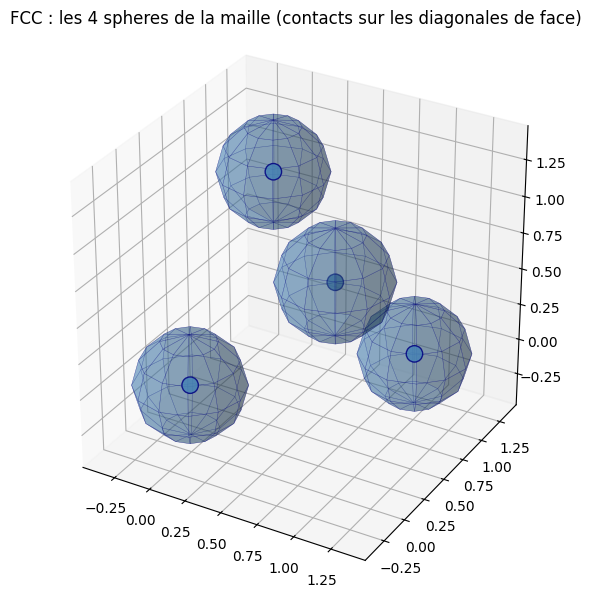

In [6]:
# FCC par la maille cubique (cote a = 1) : 4 spheres par maille,
# contact diagonale de face : 4r = a sqrt(2) -> r = sqrt(2)/4
d_fcc = 4 * vol_boule(3, sqrt(2) / 4)
print(f"FCC : densite = {d_fcc:.6f} = pi/(3 sqrt(2)) ~ 0.7405")
print("c'est LA constante de Kepler (Hales 1998, verifiee formellement 2014)")

# Rendu 3D : une maille du FCC
fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(projection="3d")
pts_fcc = [(x, y, z) for x, y, z in iproduct(range(2), repeat=3)
           if (x + y + z) % 2 == 0]
ax.scatter([p[0] for p in pts_fcc], [p[1] for p in pts_fcc], [p[2] for p in pts_fcc],
           s=140, color="steelblue", alpha=0.85, ec="navy")
import numpy as np
u = np.linspace(0, 2 * pi, 13)
v = np.linspace(0, pi, 7)
r_s = sqrt(2) / 4
for x, y, z in pts_fcc:
    xs = x + r_s * np.outer(np.cos(u), np.sin(v))
    ys = y + r_s * np.outer(np.sin(u), np.sin(v))
    zs = z + r_s * np.outer(np.ones_like(u), np.cos(v))
    ax.plot_surface(xs, ys, zs, color="steelblue", alpha=0.35,
                    linewidth=0.3, edgecolor="navy")
ax.set_title("FCC : les 4 spheres de la maille (contacts sur les diagonales de face)")
ax.set_box_aspect((1, 1, 1))
plt.tight_layout()
plt.show()

## 5. Dimensions hautes : le trou contre-intuitif

La borne de **Minkowski-Hlawka** garantit qu'en toute dimension $n$ il existe un réseau de densité $\geq 2^{1-n}$ — mais personne ne sait l'approcher. Pendant ce temps, les réseaux **exceptionnels** (E8 en dimension 8, Leech en dimension 24, tous deux optimaux — Viazovska 2016 pour E8) atteignent des densités des milliers de fois supérieures. Le contraste, mesuré :

| réseau | $n$ | demi-distance | det | densité | $2^{1-n}$ |

In [7]:
lignes = []
for n, nom, r, det in [
    (2, "Z^2 carre", 0.5, 1.0), (2, "A2 hexagonal", 0.5, sqrt(3) / 2),
    (3, "A3 (FCC)", 1 / sqrt(2), 2.0),
    (4, "D4", 1 / sqrt(2), 2.0), (8, "E8", 1 / sqrt(2), 1.0),
    (10, "Z^10", 0.5, 1.0), (24, "Leech", 1.0, 1.0),
]:
    lignes.append((n, nom, vol_boule(n, r) / det, 2 ** (1 - n)))
print(f"{'n':>3s} {'reseau':14s} {'densite':>10s} {'2^(1-n)':>10s} rapport")
for n, nom, d, mh in lignes:
    print(f"{n:3d} {nom:14s} {d:10.6f} {mh:10.2e} {d / mh:8.0f}x")
leech = lignes[-1][2]
print(f"\nLeech / Minkowski-Hlawka = {leech / 2 ** (1 - 24):.0f}x :")
print("en dimension 24, le meilleur reseau connu plane 16000 fois au-dessus")
print("de la seule borne garantissant l'EXISTENCE d'un bon reseau")

  n reseau            densite    2^(1-n) rapport
  2 Z^2 carre        0.785398   5.00e-01        2x
  2 A2 hexagonal     0.906900   5.00e-01        2x
  3 A3 (FCC)         0.740480   2.50e-01        3x
  4 D4               0.616850   1.25e-01        5x
  8 E8               0.253670   7.81e-03       32x
 10 Z^10             0.002490   1.95e-03        1x
 24 Leech            0.001930   1.19e-07    16186x

Leech / Minkowski-Hlawka = 16186x :
en dimension 24, le meilleur reseau connu plane 16000 fois au-dessus
de la seule borne garantissant l'EXISTENCE d'un bon reseau


**Lecture** : la colonne « rapport » croît brutalement — E8 est 32× au-dessus de la borne, Leech 16 000×. Le message contre-intuitif de la haute dimension : **on ne sait même pas construire explicitement** un réseau approchant Minkowski-Hlawka, alors que la nature (E8, Leech) fournit des solutions parfaites. C'est le contour exact du paysage que Hlawka, Minkowski et leurs héritiers ont tracé — et où la théorie des nombres moderne, celle de Serre, puise ses constantes.

## Exercices

### Exercice 1 — Énumérer un réseau dans un disque

Écrivez `points_dans_disque(A, R)` qui renvoie tous les points du réseau $A \cdot \mathbb{Z}^2$ dans le disque **ouvert** de rayon $R$ (parcourir une fenêtre d'indices $(u,v)$ assez grande, convertir, filtrer). Vérifiez sur le réseau hexagonal avec $R = 1{,}9$ : vous devez trouver **13 points** — l'origine, six voisins à distance $1$, et six voisins à distance $\sqrt{3}$.

In [8]:
# Exercice 1 : points d'un reseau dans un disque ouvert.
def points_dans_disque(A, R):
    """Tous les (x, y) = A . (u, v) avec x^2 + y^2 < R^2."""
    # Etape 1 : borne d'indices m assez large (m ~ R / (plus petite colonne) + 2)
    # Etape 2 : pour u, v dans [-m, m] : x, y = A . (u, v) ; garder si norme < R
    return None  # TODO etudiant

### Exercice 2 — Le critère de Fermat pour tous les entiers

Fermat characterise aussi les sommes de deux carrés en général : $n$ est somme de deux carrés **ssi** chaque facteur premier $q \equiv 3 \pmod 4$ de $n$ apparaît avec un exposant **pair**. Écrivez `est_somme_de_deux_carres(n)` (factorisation + critère) et validez-la contre l'énumération brute $u^2 + v^2 = n$ pour tout $n < 200$.

In [9]:
# Exercice 2 : critere de Fermat, valide par enumeration croisee.
def est_somme_de_deux_carres(n):
    """True ssi tout facteur premier 3 mod 4 de n a un exposant pair."""
    # Etape 1 : factoriser n en parcourant d = 2, 3, 4, ... (d*d <= residu)
    # Etape 2 : pour chaque facteur d avec d % 4 == 3 : retourner False si exposant impair
    # Etape 3 : le residu final premier > 3 mod 4 interdit aussi la somme
    return None  # TODO etudiant

### Exercice 3 — Le réseau corps centré (BCC)

Le réseau **cubique centré** place une sphère à chaque sommet et une au centre du cube : 2 sphères par maille (les 8 sommets comptent 1/8 chacun), contact le long de la **diagonale du corps** $4r = a\sqrt{3}$. Complétez `densite_bcc()` et vérifiez qu'elle rend $\pi\sqrt{3}/8 \approx 0{,}6802$ — entre le cubique simple ($\pi/6 \approx 0{,}5236$) et le FCC ($0{,}7405$).

In [10]:
# Exercice 3 : densite du reseau cubique centre.
def densite_bcc():
    """Densite du BCC : 2 spheres par maille cubique de cote 1,
    rayon r = sqrt(3)/4 (contact sur la diagonale du corps)."""
    # Renvoyer 2 * vol_boule(3, r) avec le bon r
    return None  # TODO etudiant

## Conclusion

Ce qu'on a distillé :

- la **densité** d'un empilement réseau se calcule exactement : $\mathrm{vol}(B_n(r)) / \det(\Lambda)$ — π/4, π/√12 (Thue), π/(3√2) (Kepler/Hales), mesurés ;
- le **théorème de Minkowski** est *sharp* : le carré ouvert de volume $2^n \det$ est vide, l'inégalité stricte est nécessaire ;
- la preuve de **Fermat par Minkowski** s'exécute : racine de $-1$, réseau d'indice $p$, disque de rayon $\sqrt{2p}$, $a^2 + b^2 = p$ — 29 théorèmes vérifiés sans exception ;
- en **haute dimension**, le trou entre Minkowski-Hlawka ($2^{1-n}$) et les réseaux exceptionnels (E8, Leech — 16 000×) est le vrai mystère contre-intuitif de la discipline.

Grain 3 de l'EPIC [#16334](https://github.com/jsboige/CoursIA/issues/16334) — l'hommage calculé à la géométrie des nombres que Serre a fait dialoguer avec l'analyse et la géométrie algébrique toute sa vie.

## Ressources

- Hermann Minkowski, *Geometrie der Zahlen* (1896) — l'acte fondateur.
- Thomas Hales, *A proof of the Kepler conjecture* (Ann. of Math. 2005) + preuve formelle Flyspeck (2014).
- Maryna Viazovska, *The sphere packing problem in dimensions 8 and 24* (Ann. of Math. 2017) — E8 et Leech optimaux.
- John Conway & Neil Sloane, *Sphere Packings, Lattices and Groups* — le dictionnaire des réseaux.
- Programme Serre 100 : exposé Ramon van Handel, *Les bulles diaboliques de Minkowski* (mercredi 9h30).